# Automated Pipeline Overview

## Routine, corrective and summary stages

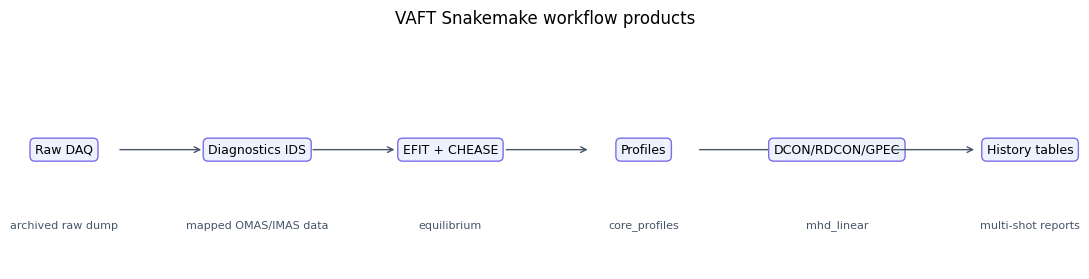

[
  {
    "stage": "Raw DAQ",
    "workflow": "routine",
    "output": "archived raw dump"
  },
  {
    "stage": "Diagnostics IDS",
    "workflow": "routine",
    "output": "mapped OMAS/IMAS data"
  },
  {
    "stage": "EFIT + CHEASE",
    "workflow": "routine",
    "output": "equilibrium"
  },
  {
    "stage": "Profiles",
    "workflow": "corrective",
    "output": "core_profiles"
  },
  {
    "stage": "DCON/RDCON/GPEC",
    "workflow": "routine",
    "output": "mhd_linear"
  },
  {
    "stage": "History tables",
    "workflow": "summary",
    "output": "multi-shot reports"
  }
]


588

In [ ]:
from pathlib import Path
import os

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import json
import matplotlib.pyplot as plt

stages = [
    ("Raw DAQ", "routine", "archived raw dump"),
    ("Diagnostics IDS", "routine", "mapped OMAS/IMAS data"),
    ("EFIT + CHEASE", "routine", "equilibrium"),
    ("Profiles", "corrective", "core_profiles"),
    ("DCON/RDCON/GPEC", "routine", "mhd_linear"),
    ("History tables", "summary", "multi-shot reports"),
]

fig, ax = plt.subplots(figsize=(11, 2.8))
ax.axis("off")
for index, (name, workflow, output) in enumerate(stages):
    x = index / (len(stages) - 1)
    ax.text(x, 0.55, name, ha="center", va="center", fontsize=9,
            bbox={"boxstyle": "round,pad=0.4", "fc": "#eef2ff", "ec": "#7c6ee6"})
    ax.text(x, 0.2, output, ha="center", va="center", fontsize=8, color="#475569")
    if index < len(stages) - 1:
        ax.annotate("", xy=(x + 0.145, 0.55), xytext=(x + 0.055, 0.55),
                    arrowprops={"arrowstyle": "->", "color": "#475569"})
fig.suptitle("VAFT Snakemake workflow products")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pipeline-overview.png", dpi=180, bbox_inches="tight")
plt.show()

summary = [{"stage": name, "workflow": workflow, "output": output} for name, workflow, output in stages]
print(json.dumps(summary, indent=2))
(OUTPUT_DIR / "pipeline-overview.txt").write_text(json.dumps(summary, indent=2) + "\n")
